## Implementing the scaling code

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as intg
from scalingOIII.scaling import *
from scalingOIII.plots import *

## Initialize the fit:
    1) Load the reference and target.
    2) Define the spectral segments.
    3) Plot the line regions: Here the scaled target spectrum is without the gaussian smoothing

In [3]:
S1 = scale( 'data/ref_keck_sm2','data/2_dct' )
S1.spectral_segments()

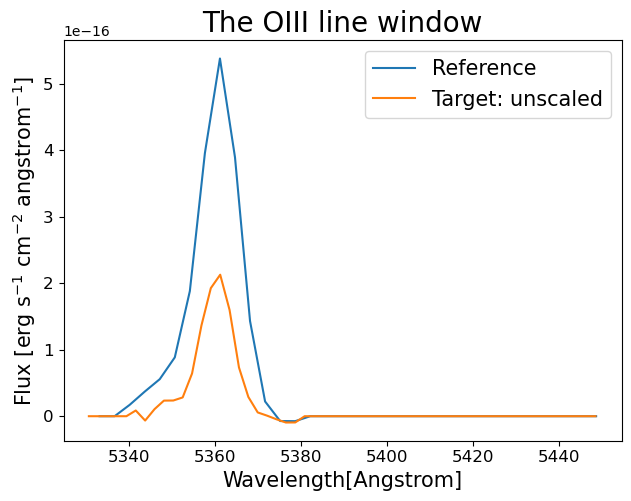

In [4]:
plot_OIII(S1.xT, S1.fl, S1.xOIII, S1.fline, Ascale=1, stat="unscaled" )

## Run the scaling Algorithm
    a) the code corrects for the [OIII] flux value by determining a scaling factor
    b) determines the amount of shift that is required to align the line centers

In [9]:
samples = S1.run_emcee( S1.xOIII, S1.fline, S1.eOIII, 1000)

100%|██████████| 1000/1000 [00:34<00:00, 28.67it/s]


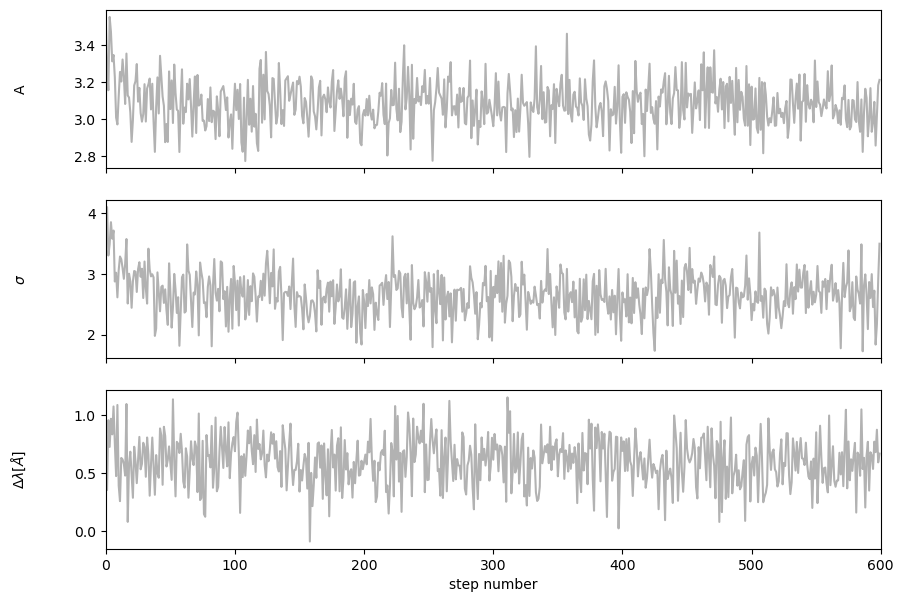

In [20]:
plot_chain(samples)

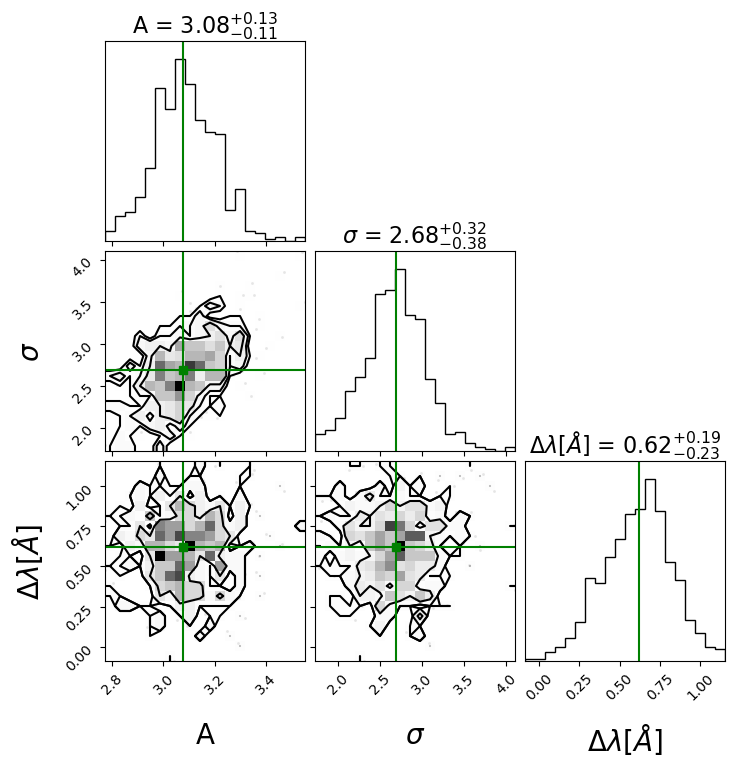

In [10]:
plot_contour(samples)

In [11]:
par = S1.best_values(samples)
l,ff,ee = S1.transform_spectrum(S1.xT, par[0], par[1], par[2])
f_transformed = intg.simpson(ff, x=l)
f_original    = intg.simpson(S1.fline, x=S1.xOIII)
print("Target_transformed/Reference = ",f_transformed/S1.R0)
print("Target_original/Reference = ",f_original*par[0]/S1.R0)

Target_transformed/Reference =  0.9701398431752569
Target_original/Reference =  0.9773353644795564


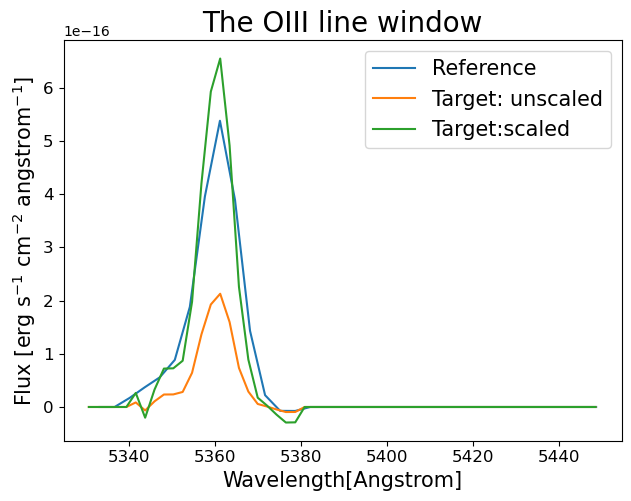

In [12]:
plot_OIII(S1.xT, S1.fl, S1.xOIII, S1.fline, Ascale=par[0], stat="scaled" )